In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv(
    "train.csv",
    engine="python",
    on_bad_lines="skip"
)



In [13]:
df.shape


(404290, 6)

In [14]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404290 entries, 0 to 404289
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404290 non-null  int64 
 1   qid1          404290 non-null  int64 
 2   qid2          404290 non-null  int64 
 3   question1     404289 non-null  object
 4   question2     404288 non-null  object
 5   is_duplicate  404290 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [16]:
df.sample(10)

,id,qid1,qid2,question1,question2,is_duplicate
197987,197987,299076,75087,Which country should I not visit?,Why should I visit your country?,0
7758,7758,15145,15146,"Between 6 new IIMs (Trichy, Ranchi and others)...","How would you choose between SPJIMR, IIM-I, II...",0
330522,330522,17408,168148,Why doesn't Hillary Clinton win the White Hous...,How could Hillary Clinton win the popular vote...,1
259753,259753,375572,375573,Have you ever been in love?,Have you ever been crazy in love?,1
67834,67834,117331,26813,How much longer will the North Korean regime l...,Why don't North Koreans revolt against the com...,0
307043,307043,61062,187488,How do you root an Android tablet?,How do I root my android to do everything?,1
124056,124056,200413,200414,How do I learn how to drive a boat?,How did you learn how to drive?,0
354627,354627,483767,483768,Do Indians travel in trains without buying tic...,Why was Bashar Al Assad laughing when Gaddafi ...,0
393953,393953,526798,526799,Is there any best dermatologist in chennai?,Who is the best dermatologist in Chennai?,0
351858,351858,178174,480739,What country catches the most lobsters?,Why are flights with Sun Country airlines so c...,0


In [17]:
## Missing Values
df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,1
question2,2
is_duplicate,0


In [18]:
# duplicated rows
df.duplicated().sum()

np.int64(0)

is_duplicate
0    255027
1    149263
Name: count, dtype: int64
is_duplicate
0    63.080215
1    36.919785
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

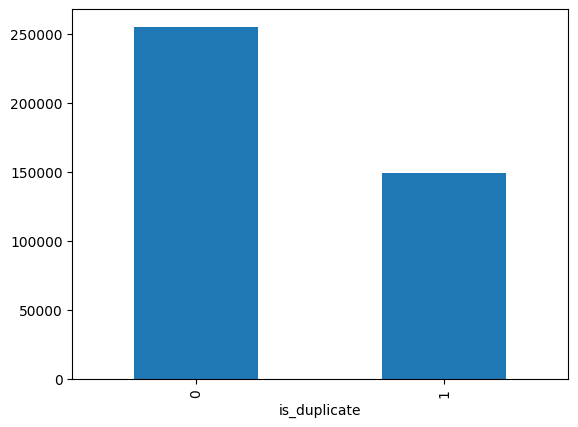

In [19]:
print(df['is_duplicate'].value_counts())
print((df['is_duplicate'].value_counts()/df['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [20]:
# Repeaated Questions
qid=pd.Series(df['qid1'].tolist()+df['qid2'].tolist())
print('Number Of Unique questions',np.unique(qid).shape[0])
x=qid.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number Of Unique questions 537933
Number of questions getting repeated 111780


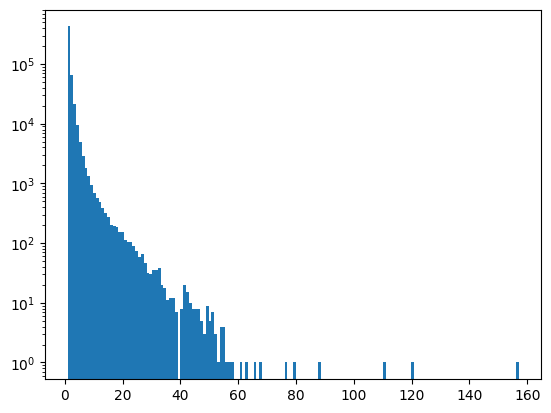

In [21]:
# Repeated Question histogram
plt.hist(qid.value_counts().values,bins=160)
plt.yscale('log')
plt.show()